Estimated parallel fraction p = 0.9215
Theoretical max speedup (N→∞) = 12.74x
Achieved speedup with 16 workers = 10.25x


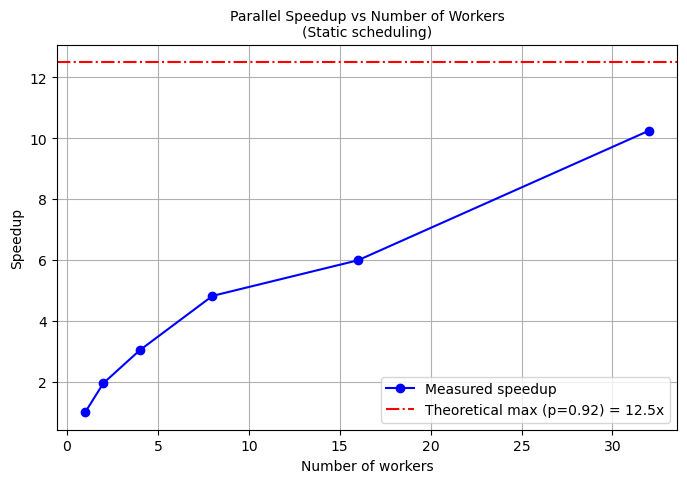

In [10]:
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

worker_counts = [1, 2, 4, 8, 16, 32]
times_static = []

for n in worker_counts:
    with open(f'task5_miniproject_{n}.err', 'r') as f:
        content = f.read()
    match = re.search(r'real\s+(\d+)m([\d.]+)s', content)
    minutes, seconds = float(match.group(1)), float(match.group(2))
    times_static.append(minutes * 60 + seconds)

baseline_static = times_static[0]
speedups_static = [baseline_static / t for t in times_static]

# Fit Amdahl's law to measured speedups to estimate p
def amdahl(N, p):
    return 1 / ((1 - p) + p / N)

popt, _ = curve_fit(amdahl, worker_counts, speedups_static, p0=[0.9], bounds=(0, 1)) #p0 = initial guess for p
p_estimated = popt[0]
max_speedup_static = 1 / (1 - p_estimated)
max_speedup_00 = 1 / (1 -  0.92)  # theoretical max speedup if p were 0.92
print(f"Estimated parallel fraction p = {p_estimated:.4f}")
print(f"Theoretical max speedup (N→∞) = {max_speedup_static:.2f}x")
print(f"Achieved speedup with 16 workers = {speedups_static[-1]:.2f}x")

# Plot
N_range = np.linspace(1, 40, 200)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(worker_counts, speedups_static, 'bo-', label='Measured speedup')
# ax.plot(worker_counts, worker_counts, 'r--', label='Ideal speedup')
# ax.plot(N_range, amdahl(N_range, p_estimated), 'g-',
    # label=f"Amdahl's law (p={p_estimated:.3f}, max={max_speedup_static:.1f}x)")
# ax.axhline(max_speedup_static, color='gray', linestyle=':', label=f'Theoretical max = {max_speedup_static:.1f}x')
ax.axhline(max_speedup_00, color='red', linestyle='-.', label=f'Theoretical max (p=0.92) = {max_speedup_00:.1f}x')
ax.set_xlabel('Number of workers')
ax.set_ylabel('Speedup')
ax.set_title('Parallel Speedup vs Number of Workers\n(Static scheduling)', fontsize=10)
ax.legend()
ax.grid(True)
plt.savefig('speedup_static.pdf')

In [12]:
# speed for 50 floorplans with 32 workers
print(f"Achieved speedup with 32 workers = {speedups_static[-1]:.2f}x")
print(f"Time with 32 workers = {times_static[-1]:.2f}s")

Achieved speedup with 32 workers = 10.25x
Time with 32 workers = 66.05s


In [6]:
for n, t, s in zip(worker_counts[1:], times_static[1:], speedups_static[1:]):
    print(f"{n} workers: time = {t:.2f}s, speedup = {s:.2f}x")
    p = (1/s - 1) / (1/n - 1)
    print(f"  Estimated p from this point = {p:.4f}")

2 workers: time = 346.49s, speedup = 1.95x
  Estimated p from this point = 0.9763
4 workers: time = 222.95s, speedup = 3.04x
  Estimated p from this point = 0.8942
8 workers: time = 140.38s, speedup = 4.82x
  Estimated p from this point = 0.9059
16 workers: time = 112.98s, speedup = 5.99x
  Estimated p from this point = 0.8886
32 workers: time = 66.05s, speedup = 10.25x
  Estimated p from this point = 0.9315


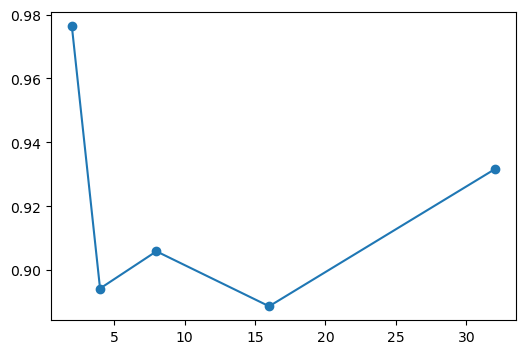

In [11]:
# plot of p 
p_values = [(1/s - 1) / (1/n - 1) for n, s in zip(worker_counts[1:], speedups_static[1:])]
plt.figure(figsize=(6, 4))
plt.plot(worker_counts[1:], p_values, 'o-') 

Achieved speedup with 32 workers = 9.15x


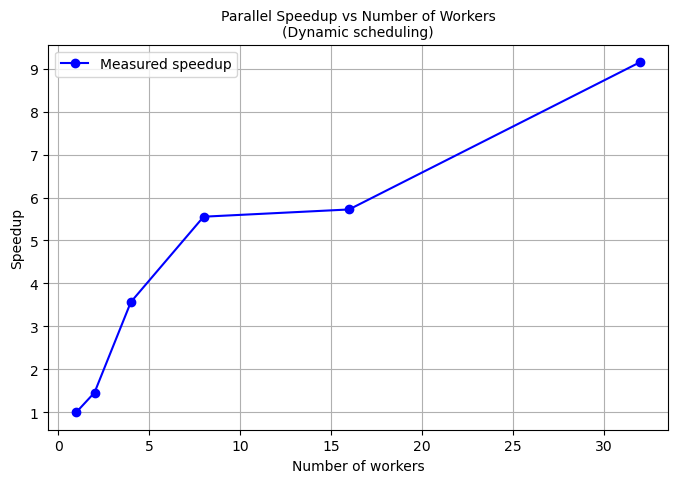

In [11]:
# same thing for dynamic allocating 
worker_counts = [1,2, 4, 8, 16, 32]
times_dynamic = []

for n in worker_counts:
    with open(f'task6_miniproject_{n}.err', 'r') as f:
        content = f.read()
    match = re.search(r'real\s+(\d+)m([\d.]+)s', content)
    minutes, seconds = float(match.group(1)), float(match.group(2))
    times_dynamic.append(minutes * 60 + seconds)

baseline_dynamic = times_dynamic[0]
speedups_dynamic = [baseline_dynamic / t for t in times_dynamic]

print(f"Achieved speedup with 32 workers = {speedups_dynamic[-1]:.2f}x")

# Plot
N_range = np.linspace(1, 40, 200)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(worker_counts, speedups_dynamic, 'bo-', label='Measured speedup')
ax.set_xlabel('Number of workers')
ax.set_ylabel('Speedup')
ax.set_title('Parallel Speedup vs Number of Workers\n(Dynamic scheduling)', fontsize=10)
ax.legend()
ax.grid(True)
plt.savefig('speedup_dynamic.pdf')

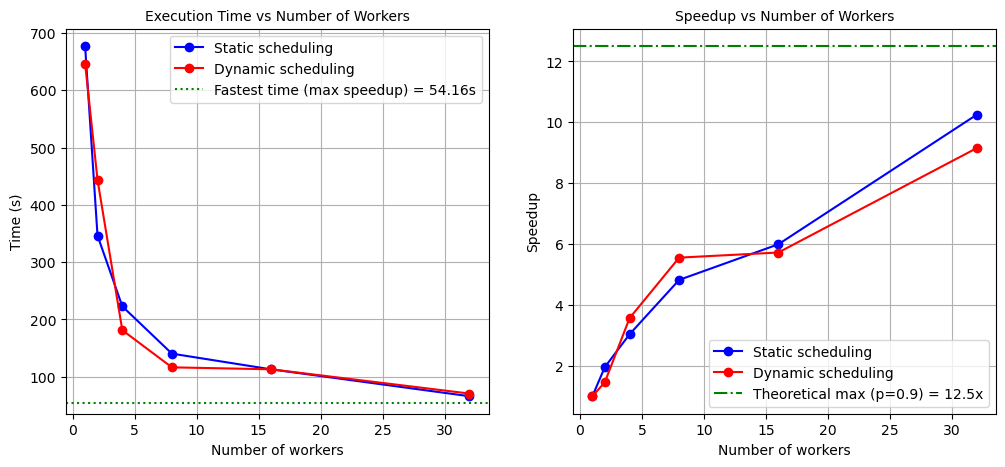

In [9]:
max_speedup_00 = 1 / (1 -  0.92)  # theoretical max speedup if p were 0.92

fig,ax = plt.subplots(1,2, figsize=(12,5))

#plot 1 dynamic and scheduling on same plot, with TIMES and not speedups
ax[0].plot(worker_counts, times_static, 'bo-', label='Static scheduling')
ax[0].plot(worker_counts, times_dynamic, 'ro-', label='Dynamic scheduling')
# fastest time with max speedup
fastest_time = times_static[0] / max_speedup_00
ax[0].axhline(fastest_time, color='green', linestyle=':', label=f'Fastest time (max speedup) = {fastest_time:.2f}s')
ax[0].set_xlabel('Number of workers')
ax[0].set_ylabel('Time (s)')
ax[0].set_title('Execution Time vs Number of Workers', fontsize=10)
ax[0].legend()
ax[0].grid(True)

# plot 2 speedups for static and dynamic on same plot
ax[1].plot(worker_counts, speedups_static, 'bo-', label='Static scheduling')
ax[1].plot(worker_counts, speedups_dynamic, 'ro-', label='Dynamic scheduling')
ax[1].axhline(max_speedup_00, color='green', linestyle='-.', label=f'Theoretical max (p=0.9) = {max_speedup_00:.1f}x')
ax[1].set_xlabel('Number of workers')   
ax[1].set_ylabel('Speedup')
ax[1].set_title('Speedup vs Number of Workers', fontsize=10)
ax[1].legend()
ax[1].grid(True)


plt.savefig('speedup_comparison.pdf')
